Начнем работу с того, что представим наш датасет в виде таблицы 

In [50]:
import pandas as pd

df = pd.read_csv("Depression.csv")
df

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22.0,Female,Science,3.50,7.3,3.3,3.4,114.0,5.0,False
1,1002,20.0,Male,Engineering,2.72,5.5,7.2,6.0,142.0,2.0,False
2,1003,20.0,Male,Medical,3.01,NaN,2.3,1.8,137.0,3.0,False
3,1004,21.0,Male,Engineering,3.63,8.1,2.0,4.6,130.0,3.0,False
4,1005,19.0,Male,Arts,3.14,6.8,2.6,4.3,4.0,6.0,False
...,...,...,...,...,...,...,...,...,...,...,...
99995,100996,24.0,Female,Medical,2.02,7.0,0.6,1.4,66.0,4.0,False
99996,100997,24.0,Male,Arts,2.33,5.0,3.6,5.2,103.0,3.0,False
99997,100998,24.0,Female,Engineering,2.23,6.5,5.8,4.1,61.0,5.0,False
99998,100999,19.0,Male,Engineering,3.61,6.1,4.8,4.9,NaN,4.0,False


ПЕРВОЕ вот прям ПЕЕЕЕЕЕРВОЕ что мы делаем, это просматриваем информацию о нашем датасете

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 95099 non-null   float64
 2   Gender              100000 non-null  object 
 3   Department          89976 non-null   object 
 4   CGPA                92970 non-null   float64
 5   Sleep_Duration      92062 non-null   float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   91947 non-null   float64
 9   Stress_Level        100000 non-null  float64
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(7), int64(1), object(2)
memory usage: 7.7+ MB


Видим пропуски. Это очен плохо. Ща посмотрим визуально

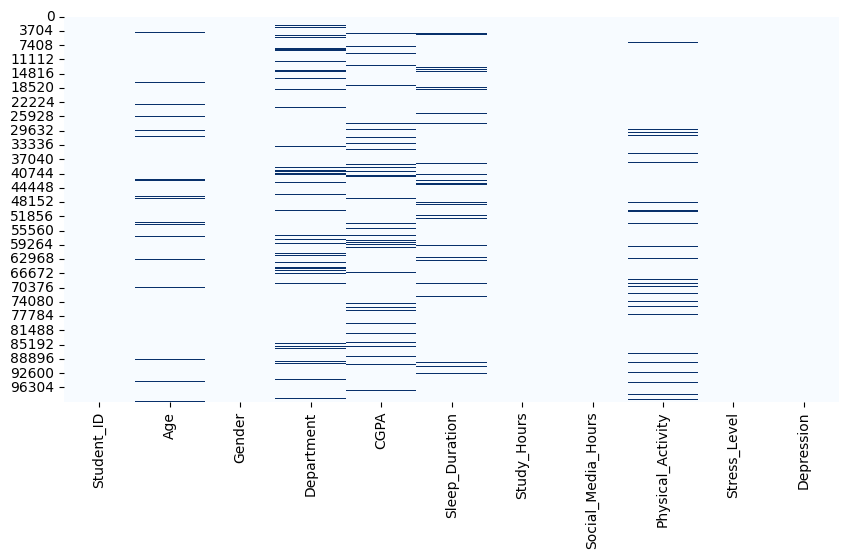

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar = False, cmap = 'Blues')
plt.show()

А вот и пропуски, их много и надо щас отдельно обработать каждый столбец, чтобы их убрать. Для начала посмотрим на количество пропусков в каждом из столбцов.

In [53]:
df.isnull().sum()

Student_ID                0
Age                    4901
Gender                    0
Department            10024
CGPA                   7030
Sleep_Duration         7938
Study_Hours               0
Social_Media_Hours        0
Physical_Activity      8053
Stress_Level              0
Depression                0
dtype: int64

Пропуски есть в 5 колонках ну там вроде видно где и скока (: 


Начинаем просматривать каждую колонку, чтобы решить на что именно мы будет заменять пропуски

### Age

оч много пропусков


Просматриваем количество уникальных значений, чтобы решить какой метод использовать

In [54]:
df['Age'].unique()

array([22., 20., 21., 19., 18., 24., nan, 23.])

Видим что в колонке записаны малые цифры, которые повторяются, поэтому содержание колонки можно считать классами.
Так как в колонке хранятся классы, просматриваем моду (самое частое значение)

In [55]:
df['Age'].mode()

0    22.0
Name: Age, dtype: float64

Обращаемся к 1 значению

In [56]:
df['Age'].mode()[0]

np.float64(22.0)

проверим, равно ли это значение (mode), математически вычесленному среднему значению.

In [57]:
df['Age'].median()

np.float64(21.0)

Ну они не равны. Вроде это ни на что не повлияет.

Заменяем пропуски на моду. 

In [58]:
df['Age'].fillna(df['Age'].mode()[0], inplace=True)

C:\Users\agera\AppData\Local\Temp\ipykernel_24992\1258158026.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mode()[0], inplace=True)


Проверка:

In [59]:
df.isnull().sum()

Student_ID                0
Age                       0
Gender                    0
Department            10024
CGPA                   7030
Sleep_Duration         7938
Study_Hours               0
Social_Media_Hours        0
Physical_Activity      8053
Stress_Level              0
Depression                0
dtype: int64

Я снова просмотрел все колонки, и убедился что пропусков в Age больше нет! Ура!

### Department

оч много пропусков


Просматриваем количество уникальных значений, чтобы решить какой метод использовать

In [60]:
df['Department'].unique()

array(['Science', 'Engineering', 'Medical', 'Arts', nan, 'Business'],
      dtype=object)

Видим что в колонке записаны малые цифры, которые повторяются, поэтому содержание колонки можно считать классами.
Так как в колонке хранятся классы, просматриваем моду (самое частое значение)

In [61]:
df['Department'].mode()

0    Engineering
Name: Department, dtype: object

Обращаемся к 1 значению

In [62]:
df['Department'].mode()[0]

'Engineering'

Медиану по строкам смотреть нельзя.

Заменяем пропуски на моду. 

In [63]:
df['Department'].fillna(df['Department'].mode()[0], inplace=True)

C:\Users\agera\AppData\Local\Temp\ipykernel_24992\1184361446.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Department'].fillna(df['Department'].mode()[0], inplace=True)


Проверка:

In [64]:
df.isnull().sum()

Student_ID               0
Age                      0
Gender                   0
Department               0
CGPA                  7030
Sleep_Duration        7938
Study_Hours              0
Social_Media_Hours       0
Physical_Activity     8053
Stress_Level             0
Depression               0
dtype: int64

Я снова просмотрел все колонки, и убедился что пропусков в Department больше нет! Ура! во второй раз!

### CGPA

оч много пропусков


Просматриваем количество уникальных значений, чтобы решить какой метод использовать

In [65]:
df['CGPA'].unique()

array([3.5 , 2.72, 3.01, 3.63, 3.14, 3.31, 2.14,  nan, 2.71, 3.36, 3.35,
       2.06, 2.05, 2.1 , 2.91, 3.33, 3.15, 3.2 , 2.19, 3.48, 3.62, 2.13,
       2.  , 3.65, 2.25, 3.17, 2.8 , 2.75, 3.03, 2.84, 1.84, 2.98, 3.49,
       2.08, 2.51, 2.79, 2.38, 3.18, 2.57, 3.34, 3.22, 2.43, 2.47, 2.52,
       3.26, 2.42, 3.37, 3.67, 2.32, 3.24, 3.25, 3.42, 2.86, 2.26, 2.88,
       3.13, 2.81, 2.2 , 2.22, 2.39, 2.96, 2.44, 2.58, 3.44, 3.27, 2.07,
       3.78, 3.86, 3.76, 2.85, 2.12, 3.54, 3.06, 2.15, 3.79, 2.34, 2.65,
       3.74, 3.66, 2.48, 2.46, 2.53, 2.36, 2.74, 3.64, 1.94, 2.33, 3.68,
       2.17, 1.83, 3.75, 3.39, 2.6 , 3.38, 3.05, 3.32, 2.92, 3.8 , 2.55,
       2.09, 2.28, 3.61, 3.11, 1.98, 3.16, 3.7 , 2.69, 1.99, 2.23, 3.12,
       2.11, 2.31, 2.35, 2.3 , 2.61, 3.43, 1.81, 2.45, 3.19, 2.54, 3.28,
       4.  , 3.29, 2.16, 3.53, 3.51, 3.21, 2.66, 2.24, 3.07, 2.68, 2.83,
       2.62, 2.21, 2.4 , 3.58, 3.46, 2.94, 2.63, 1.78, 3.59, 2.9 , 2.64,
       3.77, 3.52, 3.71, 2.76, 2.29, 3.47, 2.95, 3.

Видим что в колонке записано ну оооочень много неповторяющихся и разных цифр. С модой тут будет тяжело, поэтому найдем среднее число - медиану!

In [66]:
df['CGPA'].median()

np.float64(2.9)

Заменяем пропуски на медиану. 

In [67]:
df['CGPA'].fillna(df['CGPA'].median(), inplace=True)

C:\Users\agera\AppData\Local\Temp\ipykernel_24992\1426703167.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CGPA'].fillna(df['CGPA'].median(), inplace=True)


Проверка:

In [68]:
df.isnull().sum()

Student_ID               0
Age                      0
Gender                   0
Department               0
CGPA                     0
Sleep_Duration        7938
Study_Hours              0
Social_Media_Hours       0
Physical_Activity     8053
Stress_Level             0
Depression               0
dtype: int64

Я снова просмотрел все колонки, и убедился что пропусков в CGPA больше нет! Ура! в третий раз.

### Sleep_Duration

оч много пропусков


Просматриваем количество уникальных значений, чтобы решить какой метод использовать

In [69]:
df['Sleep_Duration'].unique()

array([  7.3       ,   5.5       ,          nan,   8.1       ,
         6.8       ,   6.5       ,   4.4       ,   7.        ,
         4.8       ,   5.7       ,   3.8       ,   5.4       ,
         5.1       ,   7.6       ,   5.3       ,   5.9       ,
         7.9       ,   9.9       ,   6.        ,  10.7       ,
         8.4       ,   4.9       ,  10.5       ,   9.1       ,
         8.5       ,   6.2       ,   8.6       ,   6.3       ,
         7.1       ,   7.4       ,   4.6       ,   6.9       ,
         6.4       ,   4.5       ,   9.3       ,   7.5       ,
         9.6       ,   7.8       ,   8.2       ,   3.        ,
         4.2       ,   6.6       ,   6.1       ,   5.8       ,
         8.        ,   6.7       ,   3.6       ,   8.8       ,
         8.9       ,   5.6       ,  10.        ,   4.7       ,
         9.        ,   8.3       ,   7.2       ,   5.2       ,
         4.        ,   9.2       ,  25.67145563,   9.5       ,
         5.        ,   8.7       ,  10.9       ,   7.7 

Видим что в колонке записано ну оооочень много неповторяющихся и разных цифр. С модой тут будет тяжело, поэтому найдем среднее число - медиану!

In [70]:
df['Sleep_Duration'].median()

np.float64(7.0)

Заменяем пропуски на медиану. 

In [71]:
df['Sleep_Duration'].fillna(df['Sleep_Duration'].median(), inplace=True)

C:\Users\agera\AppData\Local\Temp\ipykernel_24992\111714114.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sleep_Duration'].fillna(df['Sleep_Duration'].median(), inplace=True)


Проверка:

In [72]:
df.isnull().sum()

Student_ID               0
Age                      0
Gender                   0
Department               0
CGPA                     0
Sleep_Duration           0
Study_Hours              0
Social_Media_Hours       0
Physical_Activity     8053
Stress_Level             0
Depression               0
dtype: int64

Я снова просмотрел все колонки, и убедился что пропусков в Sleep_Duration больше нет! Ура! УЖЕ В четВЕЕртый раз!!!!

### Physical_Activity

оч много пропусков


Просматриваем количество уникальных значений, чтобы решить какой метод использовать

In [73]:
df['Physical_Activity'].unique()

array([114., 142., 137., 130.,   4., 129.,  73.,  68.,  82.,  nan,  95.,
       107.,  47.,  72.,  53.,  24., 145.,  31., 117.,  17., 116.,   7.,
       133.,  70.,  69.,  45.,  86., 139.,  57.,  99.,  63.,  62.,  56.,
        81.,  58.,  18., 108.,  35.,  34.,  39., 110.,  10., 100., 126.,
       131.,  74.,   8., 134., 148.,  65.,  88.,  11., 118., 120., 141.,
        38.,  94., 147.,  27.,  52.,  37., 132.,  61.,  30.,  55.,  83.,
        59., 102., 122., 135., 140., 119., 104.,  21., 101.,   2., 115.,
        54., 106.,   9.,  14.,   0.,  51.,  13.,  92.,  93., 125., 113.,
        40.,  23.,  15.,  80.,  85.,  22., 128.,  90.,  49., 105.,  60.,
        48.,  96.,  75., 121., 136., 124.,  64.,  66., 111.,  44.,   5.,
       123., 144., 127.,  79.,  67., 143., 112.,  46.,  76.,  16.,  36.,
        91., 138.,  71.,  78.,  19.,  28.,   1.,  84.,  77., 103.,  97.,
       146.,  26.,  33., 109.,  42., 149.,  12.,  50.,   6.,  41.,  25.,
        87.,   3.,  89.,  32.,  29.,  20.,  43.,  9

Видим что в колонке записано ну оооочень много неповторяющихся и разных цифр. С модой тут будет тяжело, поэтому найдем среднее число - медиану!

In [74]:
df['Physical_Activity'].median()

np.float64(74.0)

Заменяем пропуски на медиану. 

In [75]:
df['Physical_Activity'].fillna(df['Physical_Activity'].median(), inplace=True)

C:\Users\agera\AppData\Local\Temp\ipykernel_24992\3132471613.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Physical_Activity'].fillna(df['Physical_Activity'].median(), inplace=True)


Проверка:

In [76]:
df.isnull().sum()

Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64

Пропусков больше нет!

Проверочка

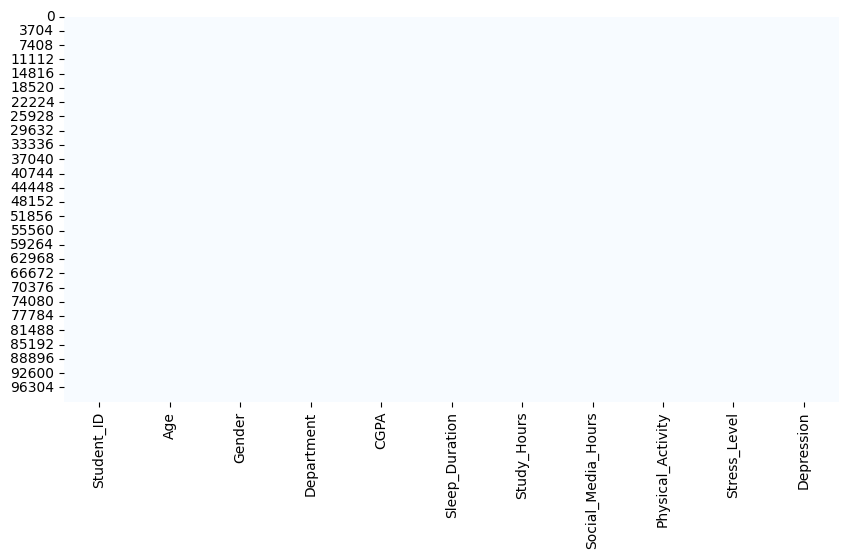

In [77]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar = False, cmap = 'Blues')
plt.show()

все белое!!

### Обработка дубликатов


In [78]:
df.duplicated().sum()

np.int64(0)

Их нету клас.

### Обратка выбросов 

In [79]:
df.describe()

,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,51000.500000,21.059000,2.898553,6.998690,4.509517,3.503574,74.319170,4.132216
std,28867.657797,1.962299,0.513262,1.451389,1.976076,1.497660,41.577849,1.435698
min,1001.000000,18.000000,1.560000,-11.146804,0.000000,-14.525312,0.000000,-15.163558
25%,26000.750000,19.000000,2.480000,6.100000,3.200000,2.500000,40.000000,3.000000
50%,51000.500000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,76000.250000,23.000000,3.310000,7.900000,5.800000,4.500000,109.000000,5.000000
max,101000.000000,24.000000,4.000000,31.307535,12.800000,23.156861,149.000000,26.432158


В таблице мы можем заметить выбросы. Их всего 3. В столбце Sleep Duration - -11, В social media hours - -14, в stress level - -15. Их наличие нелогично, ведь ты не можешь поспать там -5 часов этож бред.

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  float64
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  float64
 9   Stress_Level        100000 non-null  float64
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(7), int64(1), object(2)
memory usage: 7.7+ MB


Gender и Department нету, т.к у них тип Object. 

### Давайте разберем столбец Gender

In [81]:
df['Gender']

0        Female
1          Male
2          Male
3          Male
4          Male
          ...  
99995    Female
99996      Male
99997    Female
99998      Male
99999    Female
Name: Gender, Length: 100000, dtype: object

In [82]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [83]:
df['Gender'].value_counts()

Gender
Male      50120
Female    49880
Name: count, dtype: int64

Ну тут все нормально. Столбцов Male и Female много, и нет никаких странных значений.

### теперь Department

In [84]:
df['Department']

0            Science
1        Engineering
2            Medical
3        Engineering
4               Arts
            ...     
99995        Medical
99996           Arts
99997    Engineering
99998    Engineering
99999        Medical
Name: Department, Length: 100000, dtype: object

In [85]:
df['Department'].unique()

array(['Science', 'Engineering', 'Medical', 'Arts', 'Business'],
      dtype=object)

In [86]:
df['Department'].value_counts()

Department
Engineering    28114
Science        18065
Arts           18021
Medical        17967
Business       17833
Name: count, dtype: int64

Все нормально, аналогично с прошлым столбцом, который мы разбирали.

### Теперь избавимся от выбросов. 

Учитывая то, что единственная их проблема - отрицательность, я просто уберу из проблемных столбцов все числа меньше нуля.

In [87]:
df = df[df["Sleep_Duration"] > 0]
df = df[df["Social_Media_Hours"] > 0]
df = df[df["Stress_Level"] > 0]

In [88]:
df.describe()

,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,98906.000000,98906.000000,98906.000000,98906.000000,98906.000000,98906.000000,98906.000000,98906.000000
mean,50997.326846,21.059572,2.897955,7.000036,4.509718,3.542433,74.302954,4.133554
std,28864.339794,1.962417,0.513229,1.445985,1.975876,1.455863,41.582002,1.431507
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.100000,0.000000,2.000000
25%,26000.250000,19.000000,2.480000,6.100000,3.200000,2.500000,40.000000,3.000000
50%,50988.500000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,75994.750000,23.000000,3.310000,7.900000,5.800000,4.500000,109.000000,5.000000
max,101000.000000,24.000000,4.000000,31.307535,12.800000,23.156861,149.000000,26.432158


Воооот теперь меня все устраивает (:

### Кодируем. Gender

У нас есть 2 столбца класса object, который мы должны декодировать для того, чтобы вывести полную матрицу корелляции. Начнем с столбца Gender.

In [89]:
df = df.replace({'Gender': {'Male': 0, 'Female':1}})

C:\Users\agera\AppData\Local\Temp\ipykernel_24992\3141821200.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'Gender': {'Male': 0, 'Female':1}})


In [90]:
df['Gender'].unique()

array([1, 0])

Кодировал строки в циферки...

In [91]:
df['Gender'].value_counts()

Gender
0    49562
1    49344
Name: count, dtype: int64

### Теперь Department

In [92]:
df = df.replace({'Department': {'Science': 0, 'Engineering':1, 'Medical':2, 'Arts':3, 'Business':4}})

C:\Users\agera\AppData\Local\Temp\ipykernel_24992\2114127428.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'Department': {'Science': 0, 'Engineering':1, 'Medical':2, 'Arts':3, 'Business':4}})


In [93]:
df['Department'].unique()

array([0, 1, 2, 3, 4])

Вооот кодировал

In [94]:
df['Department'].value_counts()

Department
1    27799
0    17883
3    17829
2    17770
4    17625
Name: count, dtype: int64

Воооооот.

### Матрица корреляции

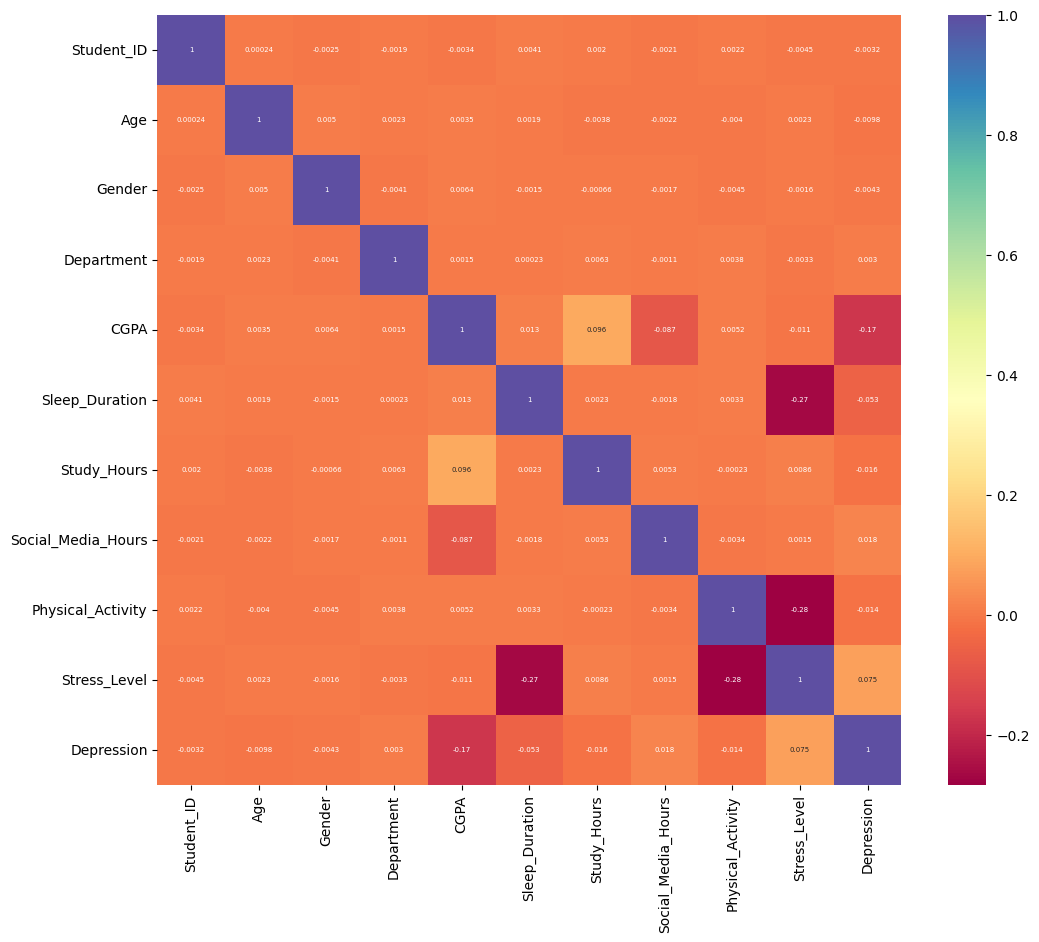

In [95]:

plt.figure(figsize=(12,10))

sns.heatmap(df.corr(),cmap="Spectral", annot= True, annot_kws={'size':5})
plt.show()

Мне не нужен такой фактор, как Student ID. Он ни на что не влияет, и по факту является лишь номером студентов. Департмент тоже удалю, тк твое самочувствие будто бы не зависит от того, в каком отделе ты учишься.

In [96]:
df = df.drop(columns=['Student_ID','Department'], axis=1)


Визуализируем

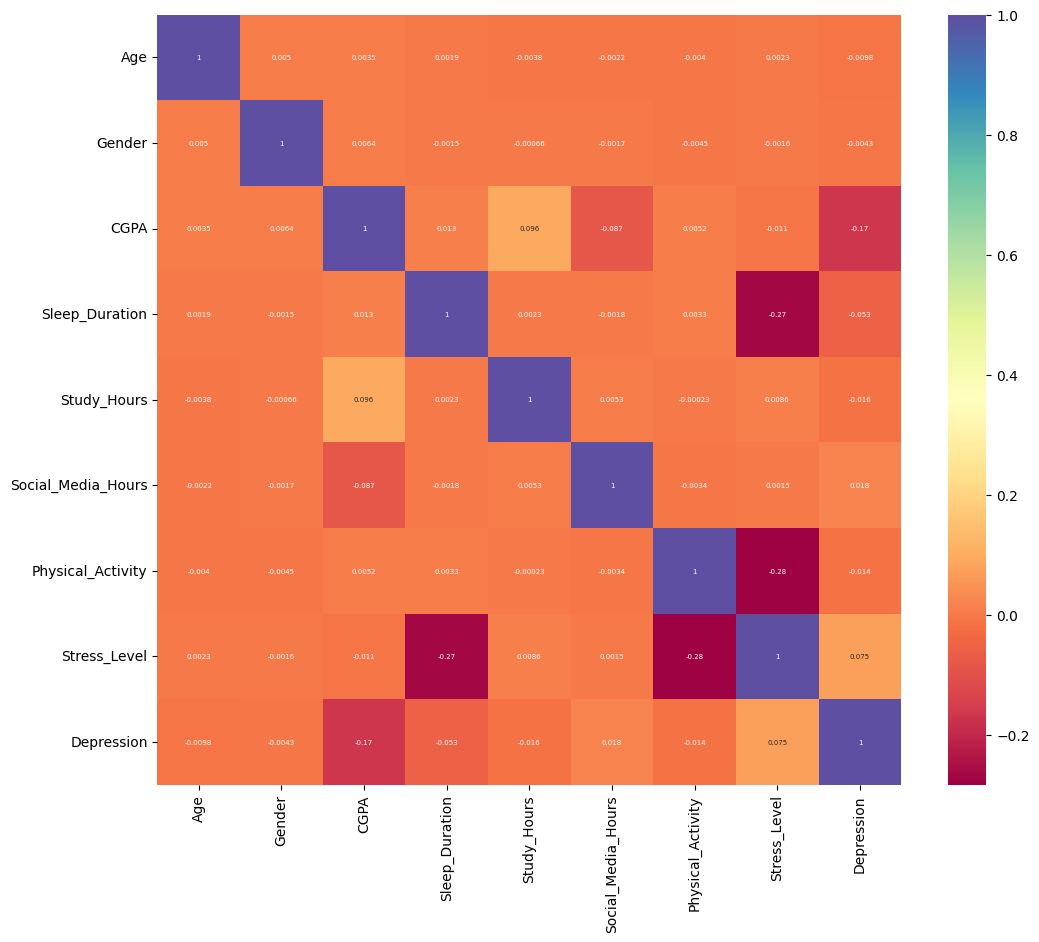

In [97]:
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(),cmap="Spectral", annot= True, annot_kws={'size':5})
plt.show()

Как будто бы теперь все логично. Учитывая то, что от одного следует другое, мы можем выявить логическую цепочку. Например связь стресса со сном большая, а вот сна с депрессией мала. Это дает нам понять то, что хоть да, сон не влияет на наличие депрессии, но вот **стресс от недостатка сна** влияет напрямую. 